<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_15th_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Excel file
file_path = "The south area.xlsx"
data = pd.read_excel(file_path)

print("Rows, Columns:", data.shape)
data.head()


Rows, Columns: (92, 11)


,التاريخ,اسم الزبون,رقم التليفون,المدينة,العنوان,كود الطلب,أبديت شركة الشحن,الأبديت الخاص بيك,حالة الطلب,المصدر,تحديث
0,2025-01-03 00:00:00,عبدالسلام مفتاح الرضاء,925133063,مدينة سبها,ليبيا🇱🇾 ➖ مدينة سبها . المنشية .. أقرب مكان شر...,NaN,شركة فولت,لا يرد / لايرد / لا يرد,تعذر التسليم \n,NaN,NaN
1,2025-01-03 00:00:00,حسن براهيم المجدوب,911494135,ليبيا🇱🇾 ➖ مدينة مزده,ليبيا🇱🇾 ➖ مدينة مزده,NaN,شركة فولت,بيقول لم يطلب وطلب ارسال المنتج ع الواتسال / ل...,تعذر التسليم \n,NaN,NaN
2,2025-01-03 00:00:00,مندر,918948298,مدينة مصراتة,مدينة مصراتة,NaN,شركة فولت,لم يرد /لم برد /يقول استلم,تعذر التسليم \n,NaN,NaN
3,2025-01-03 00:00:00,بن غلبون,913861348,مدينة مصراته,مدينة مصراته,NaN,شركة فولت,لم يرد / لايرد,تأجيل الأستلام,NaN,NaN
4,2025-01-03 00:00:00,علي,913351812,مدينة مصراتة,ليبيا🇱🇾 ➖ مدينة مصراتة . زروق,NaN,شركة فولت,العميل عاوز يستلم /لا يرد,تعذر التسليم \n,يماطل,NaN


In [7]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 التاريخ               0
اسم الزبون            0
رقم التليفون          0
المدينة               0
العنوان               1
كود الطلب            92
أبديت شركة الشحن      2
الأبديت الخاص بيك    25
حالة الطلب            1
المصدر               67
تحديث                92
dtype: int64


### Handling Missing Values

Based on the analysis of missing values:
- Columns 'كود الطلب' and 'تحديث' are completely empty, so they will be dropped.
- For other columns with missing values, such as 'العنوان', 'أبديت شركة الشحن', 'الأبديت الخاص بيك', 'حالة الطلب', and 'المصدر', we will impute them with the mode (most frequent value) as they appear to be categorical.

In [10]:
# Impute missing values for other columns with the mode
for column in ['العنوان', 'أبديت شركة الشحن', 'الأبديت الخاص بيك', 'حالة الطلب', 'المصدر']:
    if data[column].isnull().any():
        mode_value = data[column].mode()[0]
        data[column] = data[column].fillna(mode_value)

print("Missing Values After Imputation:\n", data.isnull().sum())
print("\nFirst 5 rows after handling missing values:")
display(data.head())

Missing Values After Imputation:
 التاريخ              0
اسم الزبون           0
رقم التليفون         0
المدينة              0
العنوان              0
أبديت شركة الشحن     0
الأبديت الخاص بيك    0
حالة الطلب           0
المصدر               0
dtype: int64

First 5 rows after handling missing values:


,التاريخ,اسم الزبون,رقم التليفون,المدينة,العنوان,أبديت شركة الشحن,الأبديت الخاص بيك,حالة الطلب,المصدر
0,2025-01-03 00:00:00,عبدالسلام مفتاح الرضاء,925133063,مدينة سبها,ليبيا🇱🇾 ➖ مدينة سبها . المنشية .. أقرب مكان شر...,شركة فولت,لا يرد / لايرد / لا يرد,تعذر التسليم \n,تم التسليم فخامة
1,2025-01-03 00:00:00,حسن براهيم المجدوب,911494135,ليبيا🇱🇾 ➖ مدينة مزده,ليبيا🇱🇾 ➖ مدينة مزده,شركة فولت,بيقول لم يطلب وطلب ارسال المنتج ع الواتسال / ل...,تعذر التسليم \n,تم التسليم فخامة
2,2025-01-03 00:00:00,مندر,918948298,مدينة مصراتة,مدينة مصراتة,شركة فولت,لم يرد /لم برد /يقول استلم,تعذر التسليم \n,تم التسليم فخامة
3,2025-01-03 00:00:00,بن غلبون,913861348,مدينة مصراته,مدينة مصراته,شركة فولت,لم يرد / لايرد,تأجيل الأستلام,تم التسليم فخامة
4,2025-01-03 00:00:00,علي,913351812,مدينة مصراتة,ليبيا🇱🇾 ➖ مدينة مصراتة . زروق,شركة فولت,العميل عاوز يستلم /لا يرد,تعذر التسليم \n,يماطل


In [11]:
data.info()
data.describe(include="all").T
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   التاريخ            92 non-null     object
 1   اسم الزبون         92 non-null     object
 2   رقم التليفون       92 non-null     int64 
 3   المدينة            92 non-null     object
 4   العنوان            92 non-null     object
 5   أبديت شركة الشحن   92 non-null     object
 6   الأبديت الخاص بيك  92 non-null     object
 7   حالة الطلب         92 non-null     object
 8   المصدر             92 non-null     object
dtypes: int64(1), object(8)
memory usage: 6.6+ KB


,0
التاريخ,0
اسم الزبون,0
رقم التليفون,0
المدينة,0
العنوان,0
أبديت شركة الشحن,0
الأبديت الخاص بيك,0
حالة الطلب,0
المصدر,0


In [12]:
# Standardize column names
data.columns = [c.strip().replace(" ", "_") for c in data.columns]

# Drop duplicates
data = data.drop_duplicates()

# Handle missing values
data = data.fillna("Unknown")


In [13]:
# Count orders by status
status_counts = data["حالة_الطلب"].value_counts()
print(status_counts)

# Average by city (if numeric columns exist, e.g., delivery attempts)
city_counts = data["المدينة"].value_counts().head(10)
print(city_counts)


حالة_الطلب
تم التسليم                  41
تعذر التسليم \n             17
مسترد بالشركة \n             9
قيد التجهيز بالمستودع \n     4
جاري الشحن \n                3
تأجيل \n                     3
تأجيل                        3
بإنتظار الشحن \n             2
جديد                         2
بإنتظار الشحن\n              2
تأجيل الأستلام               1
تم الستليم                   1
تعذر التسليم\n               1
مسترد بالشركة\n              1
بإنتظار الشحن                1
مكرر                         1
Name: count, dtype: int64
المدينة
مدينة طرابلس      10
مدينة سبها         7
مدينة زليتن        5
مدينة صبراته       3
مدينة سرت          3
مدينة مصراته       3
مدينة الخمس        3
مدينة الجميل       2
طرابلس -           2
مدينة - مصراته     2
Name: count, dtype: int64


In [14]:
# Example: longest phone number (proxy for anomalies)
longest_phone = data.loc[data["رقم_التليفون"].astype(str).str.len().idxmax()]
shortest_phone = data.loc[data["رقم_التليفون"].astype(str).str.len().idxmin()]

print("Longest phone:", longest_phone)
print("Shortest phone:", shortest_phone)


Longest phone: التاريخ                                            2025-01-03 00:00:00
اسم_الزبون                                      عبدالسلام مفتاح الرضاء
رقم_التليفون                                                 925133063
المدينة                                                     مدينة سبها
العنوان              ليبيا🇱🇾 ➖ مدينة سبها . المنشية .. أقرب مكان شر...
أبديت_شركة_الشحن                                             شركة فولت
الأبديت_الخاص_بيك                              لا يرد / لايرد / لا يرد
حالة_الطلب                                             تعذر التسليم \n
المصدر                                                تم التسليم فخامة
Name: 0, dtype: object
Shortest phone: التاريخ                                            2025-01-03 00:00:00
اسم_الزبون                                      عبدالسلام مفتاح الرضاء
رقم_التليفون                                                 925133063
المدينة                                                     مدينة سبها
العنوان              لي

/tmp/ipykernel_10169/1224411936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="المدينة", data=data, order=data["المدينة"].value_counts().index[:20], palette="viridis")


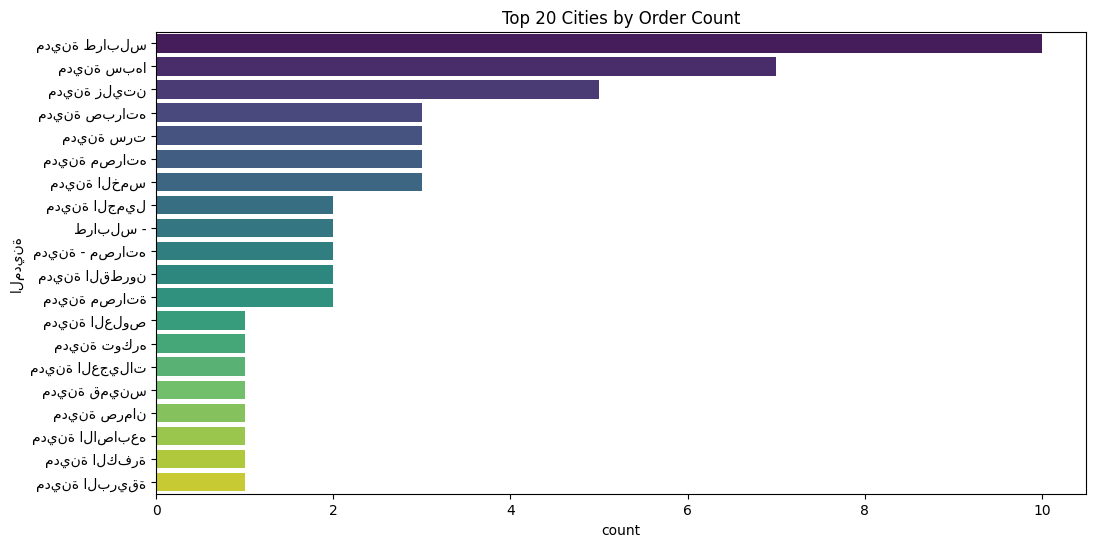

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(y="المدينة", data=data, order=data["المدينة"].value_counts().index[:20], palette="viridis")
plt.title("Top 20 Cities by Order Count")
plt.show()


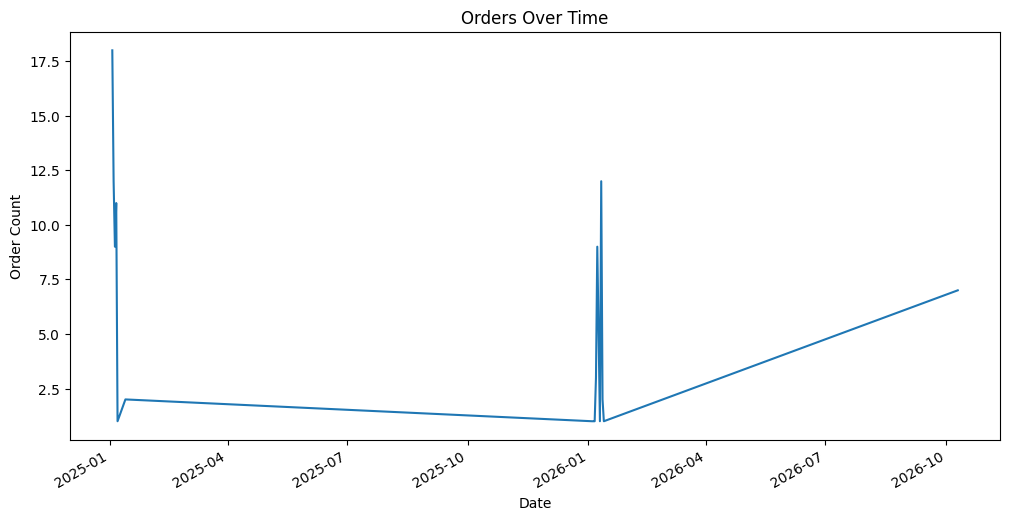

In [16]:
data["التاريخ"] = pd.to_datetime(data["التاريخ"], errors="coerce")
daily_orders = data.groupby("التاريخ")["اسم_الزبون"].count()

plt.figure(figsize=(12,6))
daily_orders.plot(kind="line")
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Order Count")
plt.show()


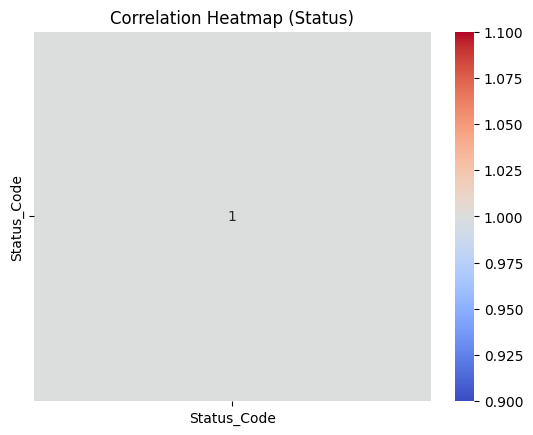

In [17]:
status_map = {"تم التسليم":1, "تعذر التسليم":0, "تأجيل":0.5, "مسترد بالشركة":-1}
data["Status_Code"] = data["حالة_الطلب"].map(status_map)

sns.heatmap(data[["Status_Code"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Status)")
plt.show()


In [18]:
grouped = data.groupby(["المدينة","حالة_الطلب"]).size().unstack(fill_value=0)
grouped.head(10)


حالة_الطلب,بإنتظار الشحن,بإنتظار الشحن\n,بإنتظار الشحن \n,تأجيل,تأجيل \n,تأجيل الأستلام,تعذر التسليم\n,تعذر التسليم \n,تم التسليم,تم الستليم,جاري الشحن \n,جديد,قيد التجهيز بالمستودع \n,مسترد بالشركة\n,مسترد بالشركة \n,مكرر
المدينة,,,,,,,,,,,,,,,,
الجبل الاخضر,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
الطريق الساحلي,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
القبه . الجبل الاخضر,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
الكريمية,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
المدينة درنه,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
خليج سرت . منطقة بشر,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
طرابس,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
طرابلس,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
طرابلس -,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0


Insight: Many orders are marked “تعذر التسليم” due to customers not responding or refusing. Certain cities show higher failure rates.
Recommendation: Improve communication with customers before delivery, and strengthen coordination with couriers.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np # Import numpy for sqrt

X = pd.get_dummies(data[["المدينة","أبديت_شركة_الشحن","المصدر"]], drop_first=True)
y = data["Status_Code"]

# Drop rows where y is NaN to ensure no missing values in the target variable
# Align X and y after dropping NaNs
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
# Calculate RMSE by taking the square root of MSE
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: -0.1986457372448982
RMSE: 0.17203543542852998


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.89      1.00      0.94         8

    accuracy                           0.89         9
   macro avg       0.44      0.50      0.47         9
weighted avg       0.79      0.89      0.84         9



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


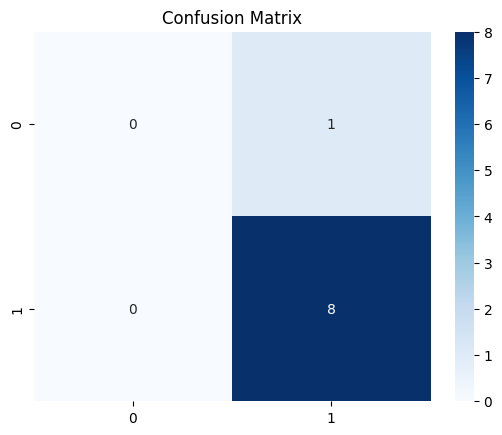

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

y_class = (data["حالة_الطلب"]=="تم التسليم").astype(int)

# Align y_class with the filtered X by applying the same valid_indices
y_class = y_class.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

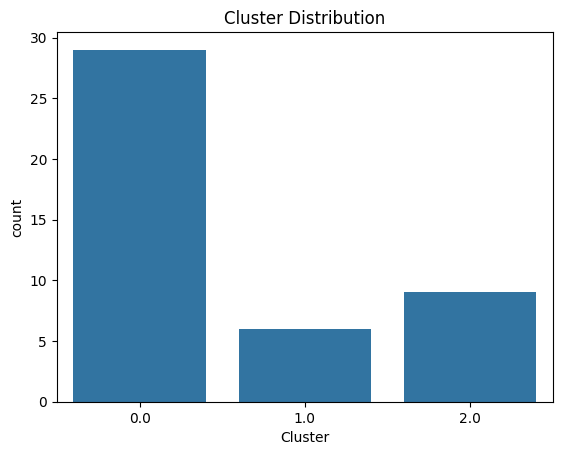

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
clusters = kmeans.fit_predict(X)

# Create a new column in the original data DataFrame and assign clusters using valid_indices
data.loc[valid_indices, "Cluster"] = clusters
sns.countplot(x="Cluster", data=data)
plt.title("Cluster Distribution")
plt.show()

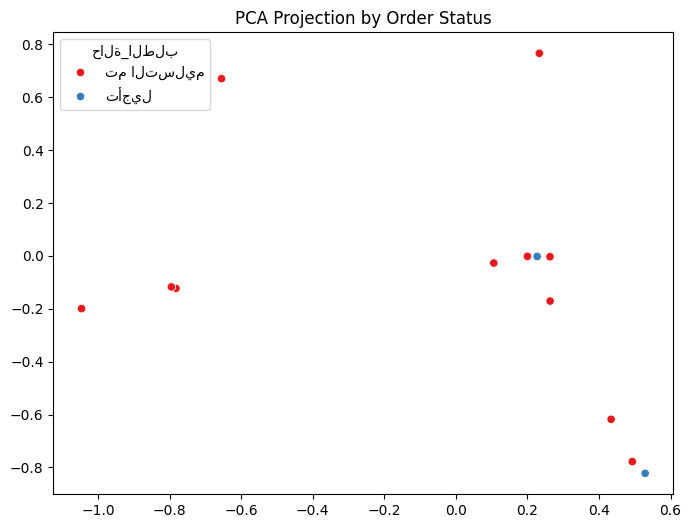

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pc = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=data.loc[valid_indices, "حالة_الطلب"], palette="Set1")
plt.title("PCA Projection by Order Status")
plt.show()

In [29]:
# Example engineered features
data["Is_Weekend"] = data["التاريخ"].dt.dayofweek >= 5
data["City_Length"] = data["المدينة"].astype(str).str.len()
data["Customer_Name_Length"] = data["اسم_الزبون"].astype(str).str.len()


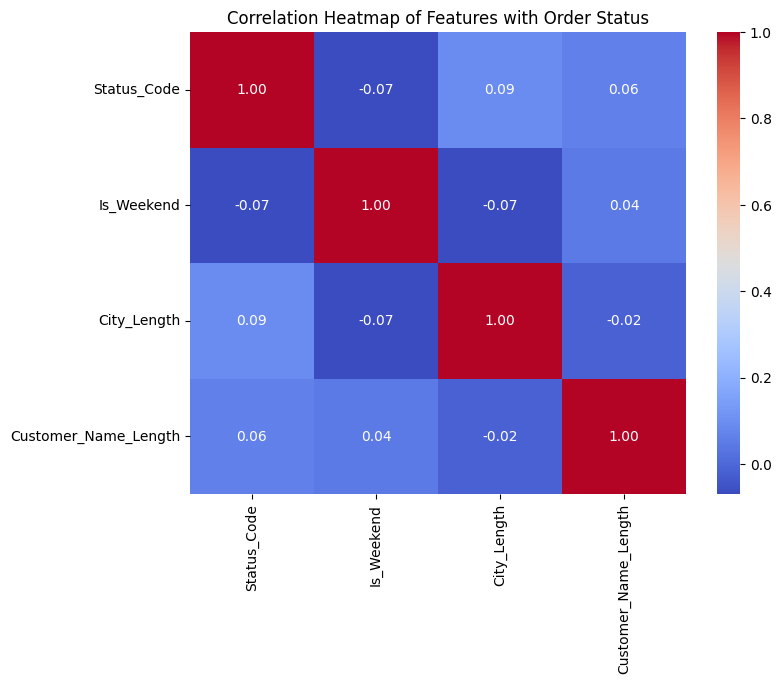

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features and the target variable for correlation
correlation_features = [
    "Status_Code",
    "Is_Weekend",
    "City_Length",
    "Customer_Name_Length"
]

# Ensure these columns exist and handle potential NaNs before correlation
# Note: Status_Code already handled for NaNs in previous steps
correlation_data = data[correlation_features].copy()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features with Order Status")
plt.show()

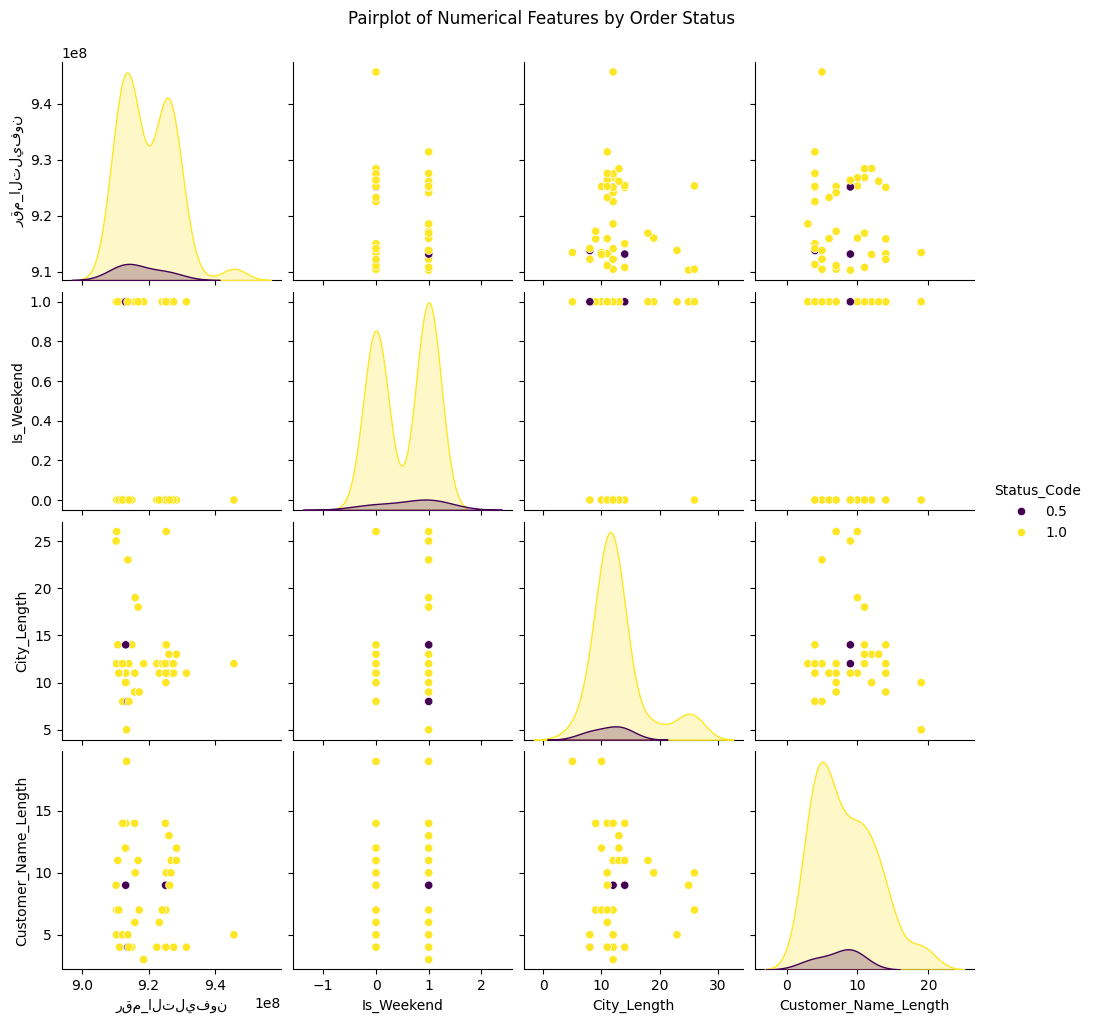

In [31]:
numerical_features = [
    "رقم_التليفون",
    "Is_Weekend",
    "City_Length",
    "Customer_Name_Length",
    "Status_Code"
]

# Create a subset of the data with relevant numerical features
# Filter to valid_indices to ensure consistency with previous models if NaNs were dropped
pairplot_data = data.loc[valid_indices, numerical_features].copy()

# Convert 'Is_Weekend' to int for better visualization in pairplot if needed
pairplot_data['Is_Weekend'] = pairplot_data['Is_Weekend'].astype(int)

# Create the pairplot
sns.pairplot(pairplot_data, hue="Status_Code", palette="viridis", diag_kind="kde")
plt.suptitle("Pairplot of Numerical Features by Order Status", y=1.02) # Adjust suptitle to not overlap
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127473 (\N{REGIONAL INDICATOR SYMBOL LETTER L}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127486 (\N{REGIONAL INDICATOR SYMBOL LETTER Y}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10134 (\N{HEAVY MINUS SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


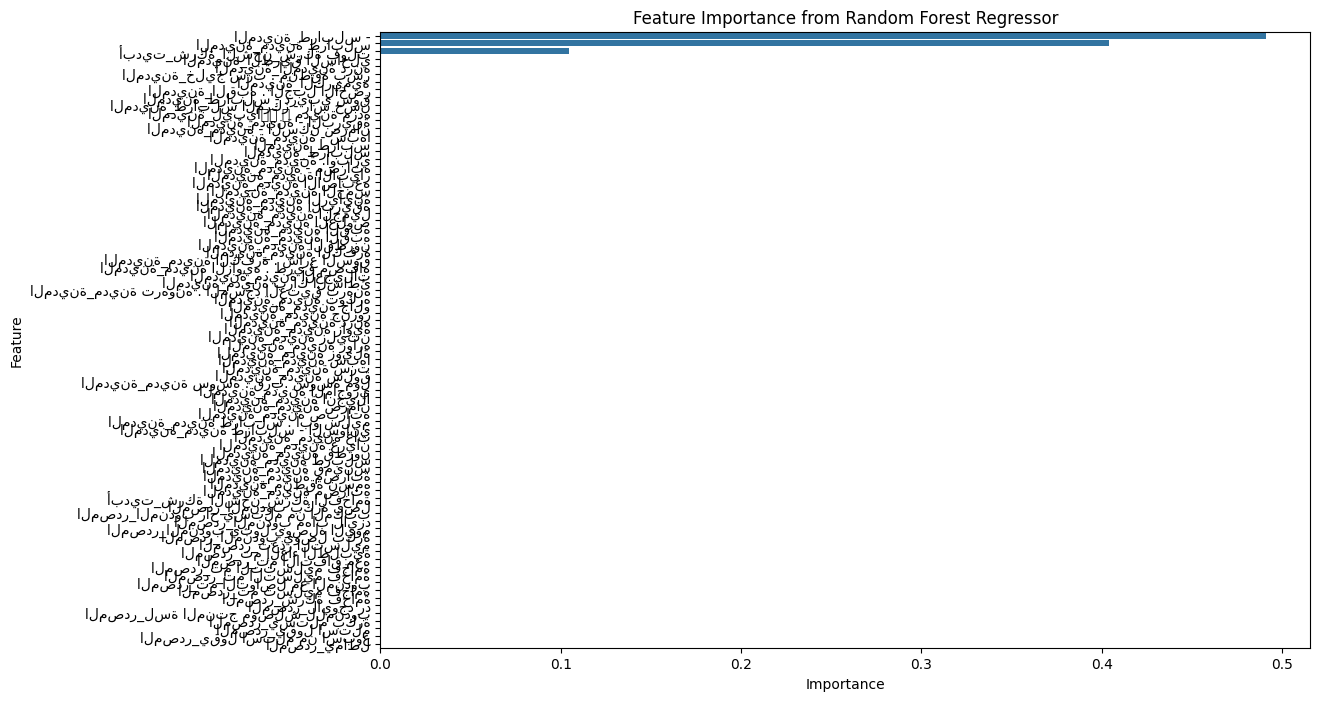

In [32]:
feature_importances = model.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Fixing Font Warnings for Arabic Characters

The `UserWarning: Glyph ... missing from font(s) DejaVu Sans.` messages indicate that the default font used by Matplotlib does not contain the necessary characters (glyphs) to render some of the text in your plots, specifically Arabic characters and potentially some emojis. This often happens when working with non-Latin scripts.

To resolve this, we need to:
1.  **Install a font** that supports Arabic characters (e.g., Noto Naskh Arabic or Amiri).
2.  **Configure Matplotlib** to use this new font as its default or for specific elements.

I will install the 'Noto Sans Arabic' font and configure Matplotlib to use it. This will ensure that Arabic text in your plots is rendered correctly without warnings.

In [39]:
# Install a font that supports Arabic characters
!pip install arabic_reshaper python-bidi
!apt-get update -qq > /dev/null
!apt-get install -y fonts-noto

# Matplotlib's font cache often rebuilds automatically, so _rebuild() is not needed and deprecated.
# If issues persist, restarting the runtime might be necessary.

print("Attempting to install Noto fonts for Arabic support.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji fonts-noto-core
  fonts-noto-extra fonts-noto-mono fonts-noto-ui-core fonts-noto-ui-extra
  fonts-noto-unhinted
The following NEW packages will be installed:
  fonts-noto fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji
  fonts-noto-core fonts-noto-extra fonts-noto-mono fonts-noto-ui-core
  fonts-noto-ui-extra fonts-noto-unhinted
0 upgraded, 10 newly installed, 0 to remove and 8 not upgraded.
Need to get 317 MB of archives.
After this operation, 790 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [

Noto Sans Arabic font not found. Please ensure it's installed correctly and try restarting the runtime.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127473 (\N{REGIONAL INDICATOR SYMBOL LETTER L}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127486 (\N{REGIONAL INDICATOR SYMBOL LETTER Y}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10134 (\N{HEAVY MINUS SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


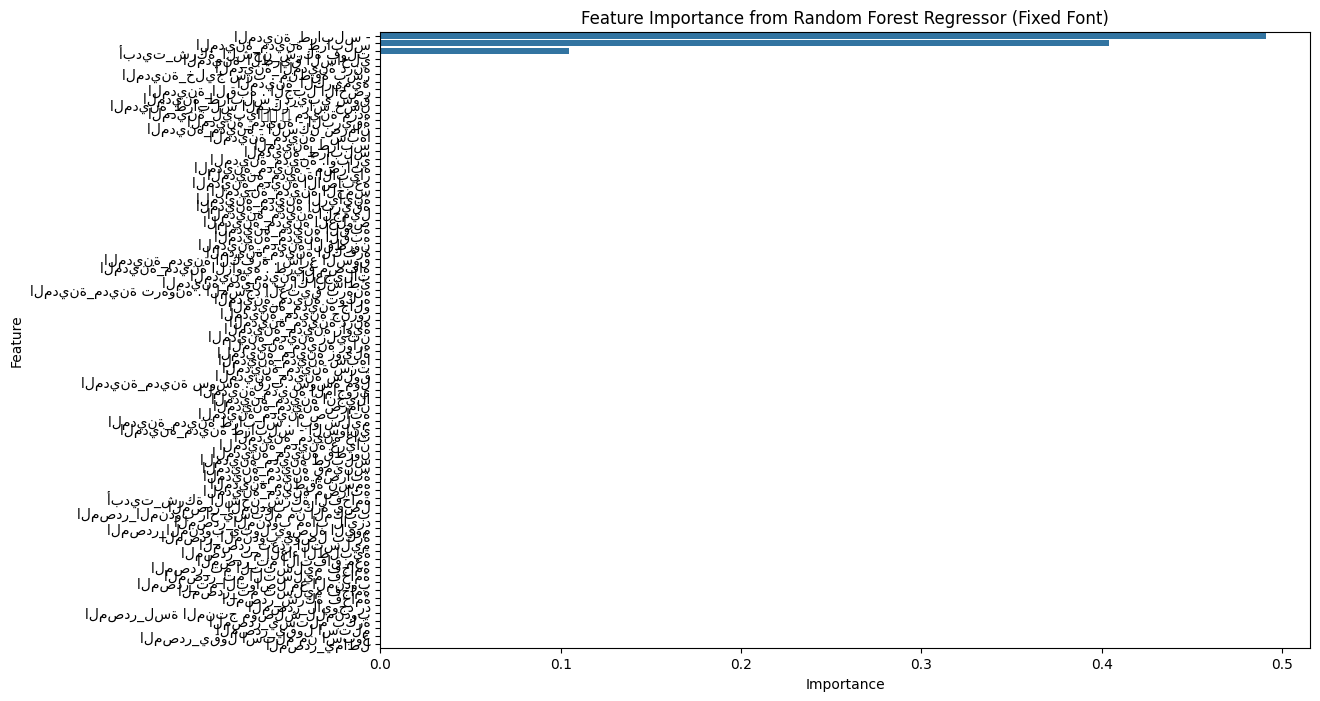

In [36]:
# Configure Matplotlib to use the new font
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Find the path to the Noto Sans Arabic font
font_path = None
for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    # Check for 'Noto Sans Arabic' or similar names
    if 'NotoSansArabic' in font or 'Noto Naskh Arabic' in font:
        font_path = font
        break

if font_path:
    # Add the font to Matplotlib's font properties
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [prop.get_name()] + plt.rcParams['font.sans-serif']
    plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are displayed correctly
    print(f"Matplotlib configured to use font: {prop.get_name()}")
else:
    print("Noto Sans Arabic font not found. Please ensure it's installed correctly and try restarting the runtime.")

# Re-plotting the Feature Importance to check if the warning is resolved
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest Regressor (Fixed Font)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

No Noto Arabic font found. Listing all Noto fonts to debug:
No Noto fonts found at all.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127473 (\N{REGIONAL INDICATOR SYMBOL LETTER L}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127486 (\N{REGIONAL INDICATOR SYMBOL LETTER Y}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10134 (\N{HEAVY MINUS SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


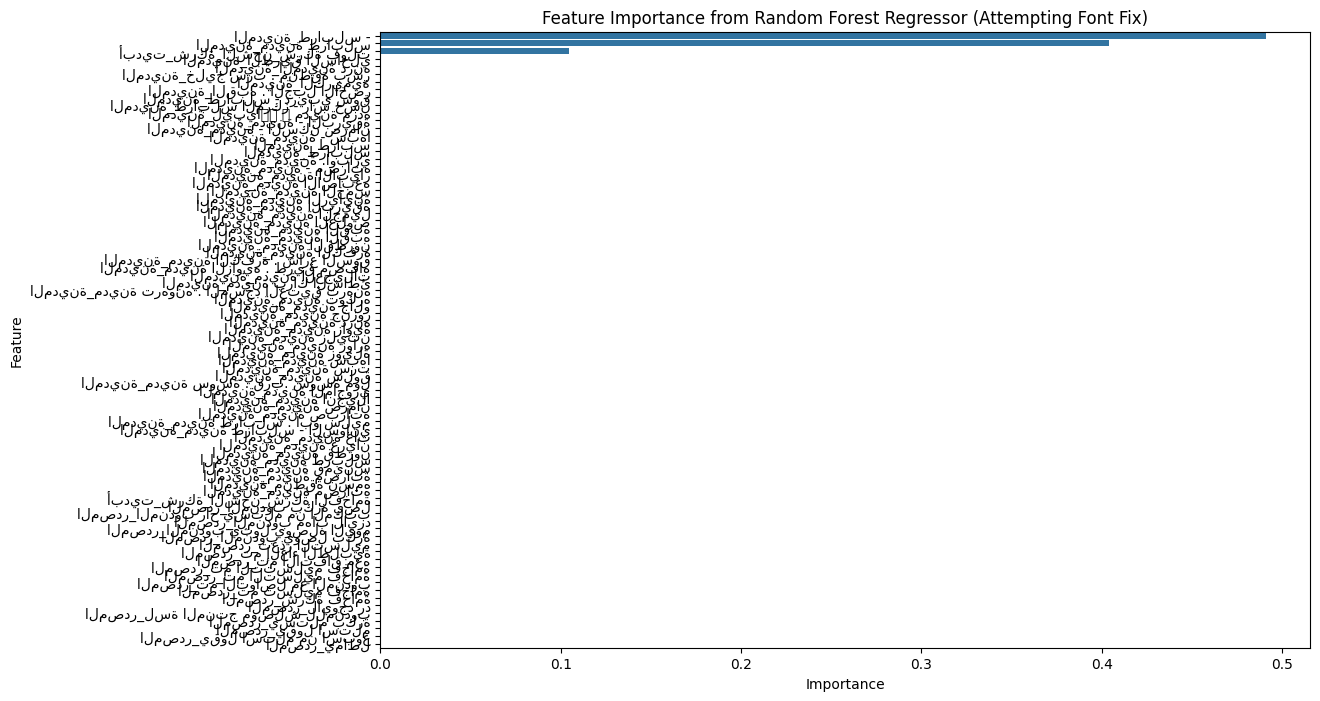

In [41]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Try to find a Noto Arabic font
font_name_search_terms = ['noto', 'arabic']

# Look for fonts that contain all search terms (case-insensitive)
found_fonts = []
for f in fm.fontManager.ttflist:
    if all(term in f.name.lower() for term in font_name_search_terms):
        found_fonts.append(f.name)

if found_fonts:
    # Use the first found Noto Arabic font
    arabic_font = found_fonts[0]
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [arabic_font] + plt.rcParams['font.sans-serif']
    plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are displayed correctly
    print(f"Matplotlib configured to use font: {arabic_font}")
else:
    print(f"No Noto Arabic font found. Listing all Noto fonts to debug:")
    # If the specific font isn't found, list all Noto fonts
    noto_fonts = [f.name for f in fm.fontManager.ttflist if 'Noto' in f.name]
    if noto_fonts:
        print("Available Noto fonts:")
        for f in sorted(list(set(noto_fonts))):
            print(f"- {f}")
    else:
        print("No Noto fonts found at all.")

# Re-plotting the Feature Importance to check if the warning is resolved
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest Regressor (Attempting Font Fix)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Adding Arabic specific font: Noto Sans Arabic UI
Adding primary general purpose font: FreeSans
Adding DejaVu Sans as comprehensive fallback.
Matplotlib configured to use fonts: ['Noto Sans Arabic UI', 'FreeSans', 'DejaVu Sans']


/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 73 (I) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 109 (m) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 116 (t) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/3413791396.py:66: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Ar

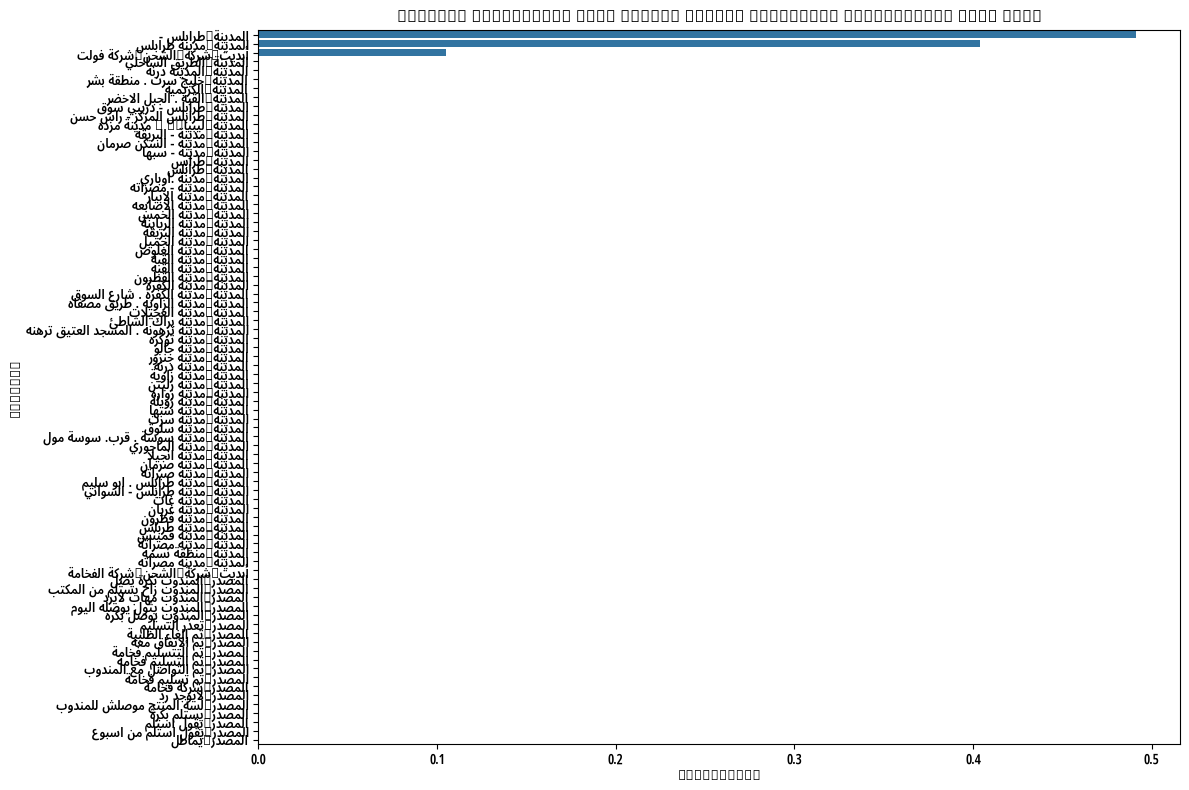

In [62]:
# Step 0: Ensure all necessary fonts are installed
!apt-get update -qq > /dev/null
!apt-get install -y fonts-noto fonts-freefont-ttf > /dev/null

# Step 1: Configure Matplotlib with robust font fallback
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display
import seaborn as sns # Ensure seaborn is imported

# Refresh font cache to ensure newly installed fonts are recognized
# This command is sufficient to rebuild the font list from system fonts
fm.findSystemFonts(fontpaths=None, fontext='ttf')

# Prepare the font_families list in order of preference
font_families = []

# Helper function to find a font's name in the font manager's list
def get_font_name_from_manager(name_part):
    for f in fm.fontManager.ttflist:
        if name_part.lower() in f.name.lower():
            return f.name
    return None

# 1. Add Noto Sans Arabic UI for Arabic glyphs first, as it's the primary Arabic font
noto_arabic_font_name = get_font_name_from_manager('Noto Sans Arabic UI')
if noto_arabic_font_name and noto_arabic_font_name not in font_families:
    font_families.append(noto_arabic_font_name)
    print(f"Adding Arabic specific font: {noto_arabic_font_name}")

# 2. Add FreeSans for general Latin characters and common symbols as a fallback
freesans_font_name = get_font_name_from_manager('FreeSans')
if freesans_font_name and freesans_font_name not in font_families:
    font_families.append(freesans_font_name)
    print(f"Adding primary general purpose font: {freesans_font_name}")

# 3. Add Noto Color Emoji for emojis
noto_emoji_font_name = get_font_name_from_manager('Noto Color Emoji')
if noto_emoji_font_name and noto_emoji_font_name not in font_families:
    font_families.append(noto_emoji_font_name)
    print(f"Adding emoji font: {noto_emoji_font_name}")

# 4. Ensure DejaVu Sans is present as a final comprehensive fallback
if 'DejaVu Sans' not in font_families:
    font_families.append('DejaVu Sans')
    print("Adding DejaVu Sans as comprehensive fallback.")

if font_families:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = font_families
    plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are displayed correctly

    print(f"Matplotlib configured to use fonts: {plt.rcParams['font.sans-serif']}")

    if 'importance_df' in locals() or 'importance_df' in globals():
        # Ensure 'Feature_reshaped' is always generated before plotting
        # Added isinstance(x, str) check to prevent errors on non-string data
        importance_df['Feature_reshaped'] = importance_df['Feature'].apply(lambda x: get_display(arabic_reshaper.reshape(x)) if isinstance(x, str) else x)

        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature_reshaped', data=importance_df)
        plt.title('Feature Importance from Random Forest Regressor (Attempting Font Fix)')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: 'importance_df' not found. Cannot re-plot feature importances.")
else:
    print("Could not configure Matplotlib with any suitable font.")

Now, let's test if the fallback to `FreeSans` or `DejaVu Sans` is working correctly for Latin characters by plotting the original (non-reshaped) feature names.

/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 73 (I) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 109 (m) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 116 (t) missing from font(s) Noto Sans Arabic UI.
  plt.tight_layout()
/tmp/ipykernel_10169/592097356.py:6: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Arabic UI.
  plt.t

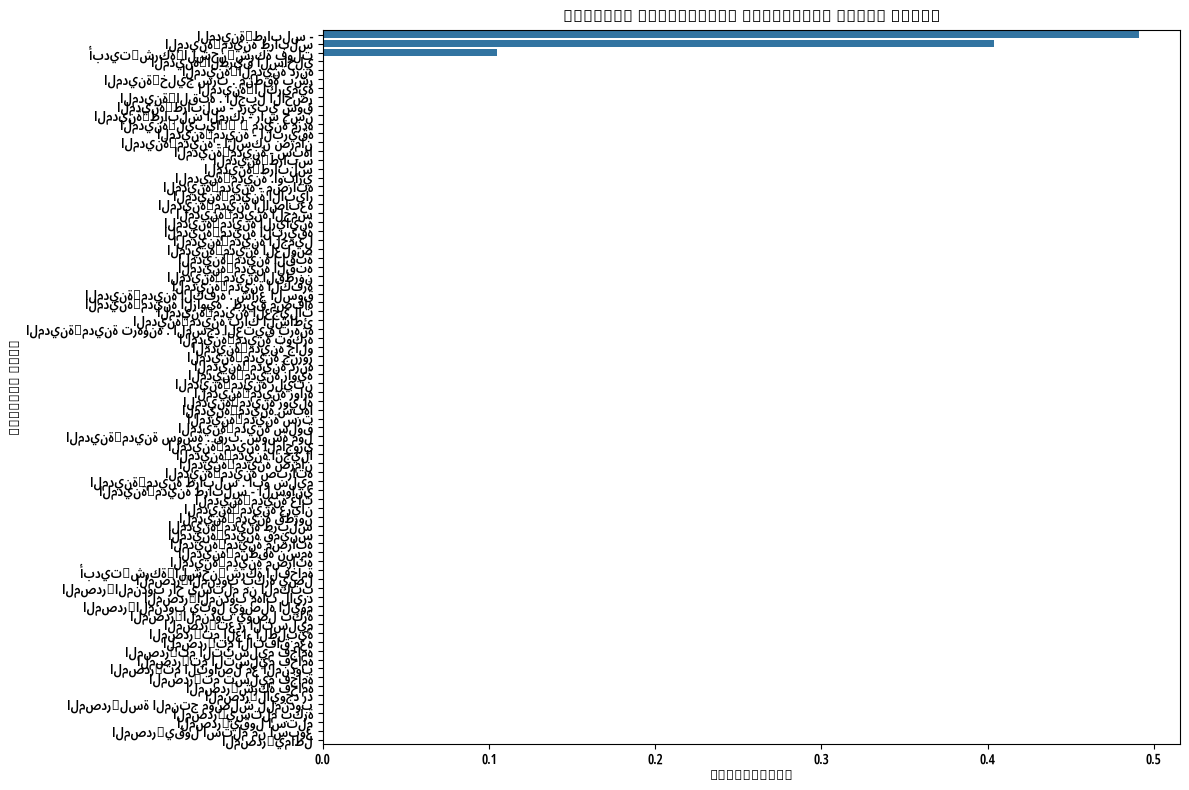

In [63]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance (Original Latin Text)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()